In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import pandas as pd

DATA_DIR = Path("../data/raw/chest_xray")
SPLITS = ["train", "val", "test"]
CLASSES = ["NORMAL", "PNEUMONIA"]

   split      class  count
0  train     NORMAL   1341
1  train  PNEUMONIA   3875
2    val     NORMAL      8
3    val  PNEUMONIA      8
4   test     NORMAL    234
5   test  PNEUMONIA    390


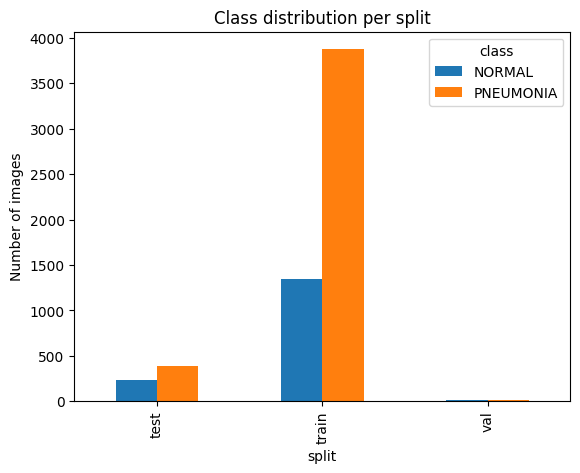

In [2]:
counts = []
for split in SPLITS:
    for cls in CLASSES:
        folder = DATA_DIR / split / cls
        n = len(list(folder.glob("*.jpeg"))) + len(list(folder.glob("*.jpg")))
        counts.append({"split": split, "class": cls, "count": n})

df_counts = pd.DataFrame(counts)
print(df_counts)

# Visualize
df_counts.pivot(index="split", columns="class", values="count").plot(kind="bar")
plt.title("Class distribution per split")
plt.ylabel("Number of images")
plt.show()

In [3]:
import random

def sample_image_properties(folder, n=50):
    files = list(folder.glob("*.jpeg")) + list(folder.glob("*.jpg"))
    sample = random.sample(files, min(n, len(files)))
    props = []
    for f in sample:
        with Image.open(f) as img:
            props.append({"width": img.width, "height": img.height, "mode": img.mode})
    return pd.DataFrame(props)

props_normal = sample_image_properties(DATA_DIR / "train" / "NORMAL")
props_pneumonia = sample_image_properties(DATA_DIR / "train" / "PNEUMONIA")

print(props_normal.describe())
print(props_normal["mode"].value_counts())
print(props_pneumonia["mode"].value_counts())

             width       height
count    50.000000    50.000000
mean   1611.920000  1268.780000
std     258.370707   242.270155
min     992.000000   808.000000
25%    1441.000000  1084.750000
50%    1670.000000  1269.500000
75%    1802.500000  1439.000000
max    2176.000000  1743.000000
mode
L    50
Name: count, dtype: int64
mode
L      45
RGB     5
Name: count, dtype: int64


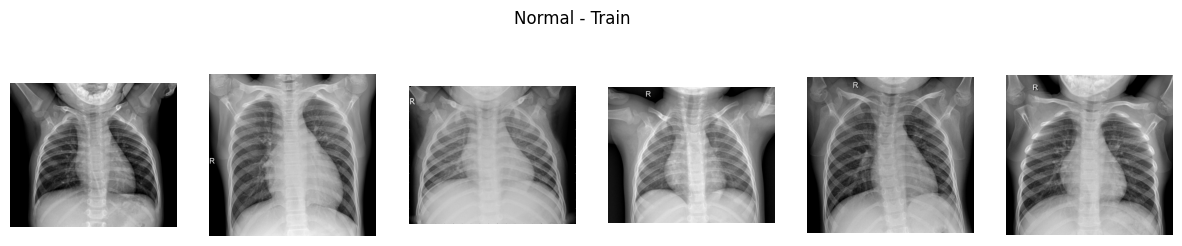

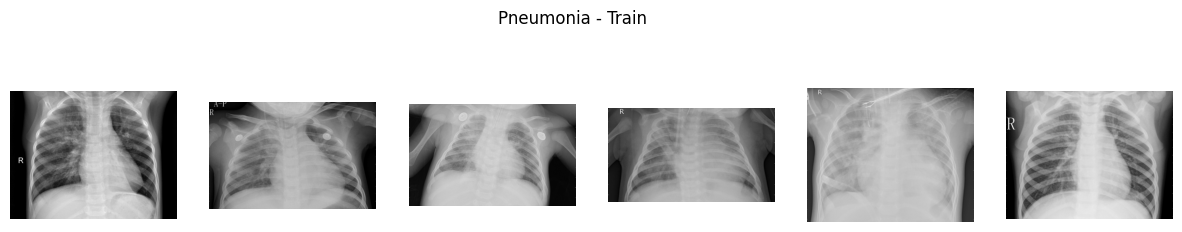

In [4]:
def plot_sample_grid(folder, title, n=6):
    files = list(folder.glob("*.jpeg")) + list(folder.glob("*.jpg"))
    sample = random.sample(files, n)
    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    for ax, f in zip(axes, sample):
        img = Image.open(f)
        ax.imshow(img, cmap="gray")
        ax.axis("off")
    fig.suptitle(title)
    plt.show()

plot_sample_grid(DATA_DIR / "train" / "NORMAL", "Normal - Train")
plot_sample_grid(DATA_DIR / "train" / "PNEUMONIA", "Pneumonia - Train")

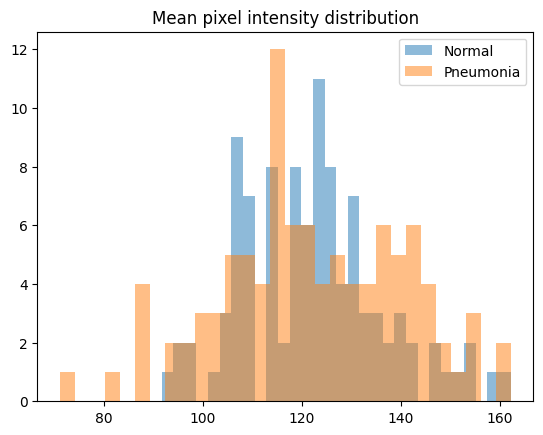

In [5]:
def get_pixel_means(folder, n=100):
    files = list(folder.glob("*.jpeg")) + list(folder.glob("*.jpg"))
    sample = random.sample(files, min(n, len(files)))
    means = []
    for f in sample:
        img = np.array(Image.open(f).convert("L"))
        means.append(img.mean())
    return means

normal_means = get_pixel_means(DATA_DIR / "train" / "NORMAL")
pneumonia_means = get_pixel_means(DATA_DIR / "train" / "PNEUMONIA")

plt.hist(normal_means, bins=30, alpha=0.5, label="Normal")
plt.hist(pneumonia_means, bins=30, alpha=0.5, label="Pneumonia")
plt.legend()
plt.title("Mean pixel intensity distribution")
plt.show()

In [6]:
def find_corrupted(folder):
    bad = []
    for f in list(folder.glob("*.jpeg")) + list(folder.glob("*.jpg")):
        try:
            img = Image.open(f)
            img.verify()
        except Exception:
            bad.append(f)
    return bad

for split in SPLITS:
    for cls in CLASSES:
        bad = find_corrupted(DATA_DIR / split / cls)
        if bad:
            print(f"{split}/{cls}: {len(bad)} corrupted files")